# "Manufacturing is coming home" — does the reshoring trade actually pay? 🏗️
### US factories + Mexico + robots: a real edge, or just high-beta sectors in a rising market?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Structural_edge%3F: Busted](https://img.shields.io/badge/Structural_edge%3F-Busted-8b949e?style=flat-square)

There's a popular trade with a great story: deglobalisation, tariffs and the COVID supply-chain scare are dragging factories back to North America — so buy **US industrials**, **Mexico** (the nearshoring winner) and **factory automation**, and you'll ride a multi-decade boom that beats the plain old market.

The basket *did* beat the market. But "beat the market" and "the reshoring story works" are two completely different claims — and only one of them survives a closer look. This notebook pulls them apart in plain English.

> 📓 **Plain-language layer.** Want the regressions, the HAC *t*-stats and the alpha math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The "reshoring trade" has no official ticker, so we **build a transparent proxy**: an equal-weight basket of **XLI** (US industrials), **EWW** (Mexico) and **ROK** (a robotics/automation name). It's a proxy, and it leans on names that *survived* — we say so throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from reshoring_basket import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real reshoring cache present:", HAVE_REAL,
      "| basket days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1999-01-05', 'end': '2026-06-18', 'days': 6906, 'years': 27.4, 'spy': (4.93, 1.98, 2.07, 4.6, 1.04, 1.93, 0.55, 0.42, 0.02), 'acwi': (3.15, 1.16, 1.24, 2.51, 1.08, 1.01, 0.46, 0.41, 0.117), 'pre': (4779, 7.6, 7.25, 2.51, 1.06, 0.55, 0.3), 'post': (2127, -1.07, -0.99, -0.24, 0.99, 0.54, 0.71), 'sleeves': [('XLI', 1.13, 0.67), ('EWW', 3.37, 0.89), ('ROK', 10.29, 2.16)], 'costs': [(5, 4.93, 4.83), (10, 4.93, 4.73), (20, 4.93, 4.53)], 'syn': [(0, 3.8, 3.49, 1.03, 1.26), (10, 13.88, 13.57, 1.03, 4.88)]}


real reshoring cache present: True | basket days: 6906


## The answer first

| Question | Answer |
|---|---|
| Did the reshoring basket beat the market? | **Yes — by about 5%/yr vs the S&P.** That's the headline the story sells. |
| Is that *reshoring working*? | **Mostly no — it's just high beta.** The basket is racier than the market (it swings ~4% harder), so in a rising market it out-earns *for free*. Strip that out and the real "edge" is small and **not statistically solid**. |
| Does it work *better* since the reshoring story got hot (2018+)? | **No — it does the opposite.** The whole edge is **before 2018**; *after* 2018, when everyone started talking reshoring, the basket actually **lagged** the market. |
| Is it really a *theme*, or a lucky stock? | **A lucky stock.** US industrials and Mexico added basically nothing; **one automation name** carries the whole headline. |

> The basket went up — because high-beta sectors go up in a bull market. The *reshoring* part added nothing you could bank, and it got worse exactly when the narrative arrived.

## 1 · The claim

> *"Globalisation is reversing. Tariffs, the pandemic supply shock and big subsidies (the IRA, the CHIPS Act) are pulling manufacturing back to the US and Mexico. Own the factories — US industrials, the robots that run them, and Mexican equities catching the nearshoring overflow — and you own a structural, multi-decade trend that beats a plain global index."*

It's a genuinely good macro story, and it's been packaged into research notes and brand-new "reshoring" ETFs. The strong version isn't "industrials are cyclical" — it's that this theme delivers something *extra*, beyond just being exposed to the market. That "extra" is what we'll go hunting for.

## 2 · So what?

Here's the trap hiding in "it beat the market." A basket of racy, cyclical sectors is **high beta** — it moves *more* than the market both ways. In a rising market (and markets rise most years) a high-beta basket out-earns the index automatically. That extra return is **not** a reshoring edge — it's just the risk you took, the same risk you could buy with a cheap leveraged index fund. The only thing worth paying a thematic premium for is **alpha**: return left over *after* you account for how much the basket just rides the market. So the real question isn't "did it beat the market?" It's "did it beat the market by **more than its beta explains** — reliably?"

## 3 · How would we even know?

We hold the basket the whole way (**27 years**, 1999-01-05 → 2026-06-18) and ask three escalating questions:

1. **Did it out-earn the market?** Compare the basket to the S&P (SPY) and to a *global* index (ACWI) — because beating the *US* market with a US-tilted basket is partly just a US bet.
2. **Is that edge real, or just beta?** Subtract out the part explained by the market (a simple regression). What's left is the honest "reshoring alpha."
3. **Does it hold up?** Split the history at **2018** — when the reshoring narrative actually began — and check each sleeve (industrials / Mexico / automation) separately. If the story is real, it should be *strongest* after 2018 and *spread across* the theme.

## 4 · The teardown — let's actually look

**First: the basket vs the market.** Here's $1 in the reshoring basket against $1 in the S&P over the whole sample. Yes — the basket wins.

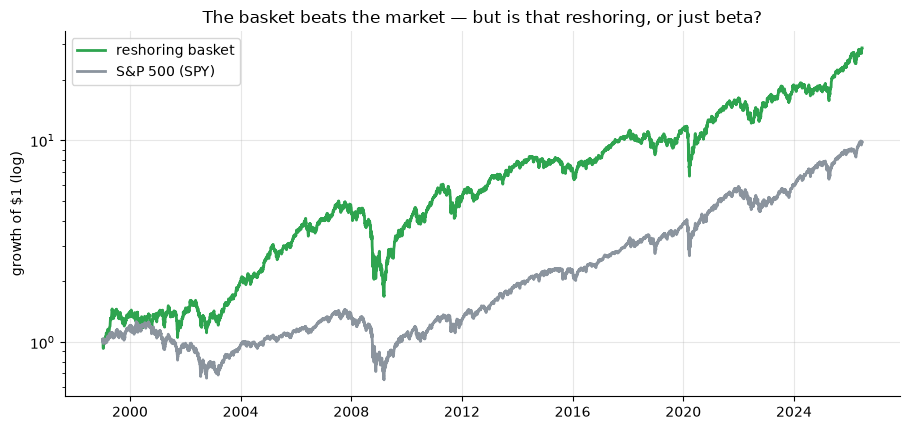

basket ended at 28.7x, market at 9.8x


In [2]:
if HAVE_REAL:
    cb = (1+F['basket']).cumprod(); cm = (1+F['mkt']).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.4))
    ax.plot(cb.index, cb.values, c=GREEN, lw=2, label='reshoring basket')
    ax.plot(cm.index, cm.values, c=GREY, lw=2, label='S&P 500 (SPY)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('The basket beats the market — but is that reshoring, or just beta?')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'basket ended at {cb.iloc[-1]:.1f}x, market at {cm.iloc[-1]:.1f}x')
else:
    print('no cache — see docs/results.md: basket excess ~+4.9%/yr vs SPY')

The basket out-earns the S&P by about **+4.9%/yr**. Case closed? Not even close — because the basket is **higher beta** than the market. Let's strip the beta out and see what's *actually* left.

**The honest edge: raw outperformance vs beta-adjusted alpha.** The grey bar is the raw market-beating return; the green bar is what survives once we subtract the part that's *just riding the market*. And we do it against both the US and the global benchmark.

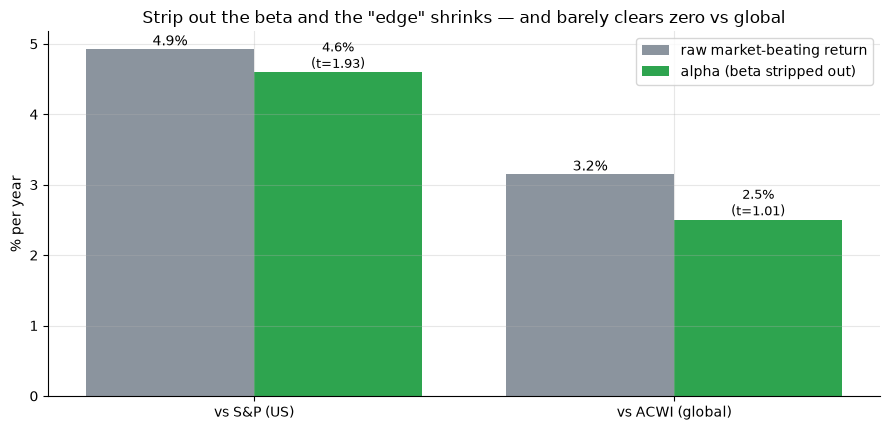

alpha vs S&P ~4.6%/yr (t=1.93); vs global ~2.5%/yr (t=1.01)


In [3]:
if HAVE_REAL:
    s_spy = st.summarize(F, 'mkt')
    fa = F.dropna(subset=['acwi']); s_acwi = st.summarize(fa, 'acwi')
    raw = [s_spy['excess_ann']*100, s_acwi['excess_ann']*100]
    alp = [s_spy['alpha_ann']*100, s_acwi['alpha_ann']*100]
    talp = [s_spy['t_alpha_hac'], s_acwi['t_alpha_hac']]
else:
    raw = [R['spy'][0], R['acwi'][0]]; alp = [R['spy'][3], R['acwi'][3]]
    talp = [R['spy'][5], R['acwi'][5]]
labels = ['vs S&P (US)', 'vs ACWI (global)']
x = np.arange(2)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, raw, .4, color=GREY, label='raw market-beating return')
ax.bar(x+.2, alp, .4, color=GREEN, label='alpha (beta stripped out)')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('% per year')
ax.set_title('Strip out the beta and the "edge" shrinks — and barely clears zero vs global')
for i,(r,a,t) in enumerate(zip(raw,alp,talp)):
    ax.annotate(f'{r:.1f}%',(i-.2,r),ha='center',va='bottom')
    ax.annotate(f'{a:.1f}%\n(t={t:.2f})',(i+.2,a),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print(f'alpha vs S&P ~{alp[0]:.1f}%/yr (t={talp[0]:.2f}); vs global ~{alp[1]:.1f}%/yr (t={talp[1]:.2f})')

There it is. Against the S&P the alpha is **+4.6%/yr** — but its reliability score (a *t*-stat; you want **2 or more**) is only **1.93**. Against the *global* index it's a thin **+2.5%/yr** at *t* = **1.01** — basically zero. The big raw number was mostly beta; the real edge is small and statistically shaky.

**Now the kill shot.** If reshoring is the *cause*, the basket should shine *most* in the reshoring era. Let's split at **2018** — the year the narrative actually started (tariffs, then COVID). Watch the alpha flip.

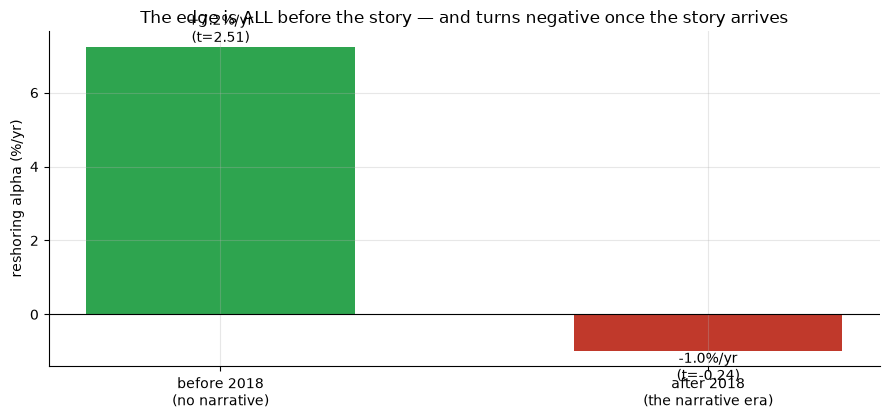

pre-2018 alpha +7.2%/yr (t=2.51); post-2018 -1.0%/yr (t=-0.24)


In [4]:
if HAVE_REAL:
    split = data.narrative_start()
    sp = st.summarize(F[F.index<split], 'mkt'); spo = st.summarize(F[F.index>=split], 'mkt')
    pre_a, post_a = sp['alpha_ann']*100, spo['alpha_ann']*100
    pre_t, post_t = sp['t_alpha_hac'], spo['t_alpha_hac']
else:
    pre_a, post_a = R['pre'][2], R['post'][2]; pre_t, post_t = R['pre'][3], R['post'][3]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
bars = ax.bar(['before 2018\n(no narrative)', 'after 2018\n(the narrative era)'],
              [pre_a, post_a], color=[GREEN, RED], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('reshoring alpha (%/yr)')
ax.set_title('The edge is ALL before the story — and turns negative once the story arrives')
for i,(a,t) in enumerate(zip([pre_a,post_a],[pre_t,post_t])):
    ax.annotate(f'{a:+.1f}%/yr\n(t={t:.2f})',(i,a),ha='center',
                va='bottom' if a>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'pre-2018 alpha {pre_a:+.1f}%/yr (t={pre_t:.2f}); post-2018 {post_a:+.1f}%/yr (t={post_t:.2f})')

The trade earned its alpha **before anyone called it reshoring** (**+7.2%/yr**, a solid *t* = 2.51) — and went **negative** (**-1.0%/yr**, *t* = -0.24) exactly in the era the story says it should win. A thesis that gets the sign of its own prediction backwards isn't driving the returns. **The narrative arrived and the edge left.**

**One more nail: it's one stock, not a theme.** If "reshoring" were real, the win should be spread across industrials, Mexico *and* automation. Let's look at each sleeve on its own.

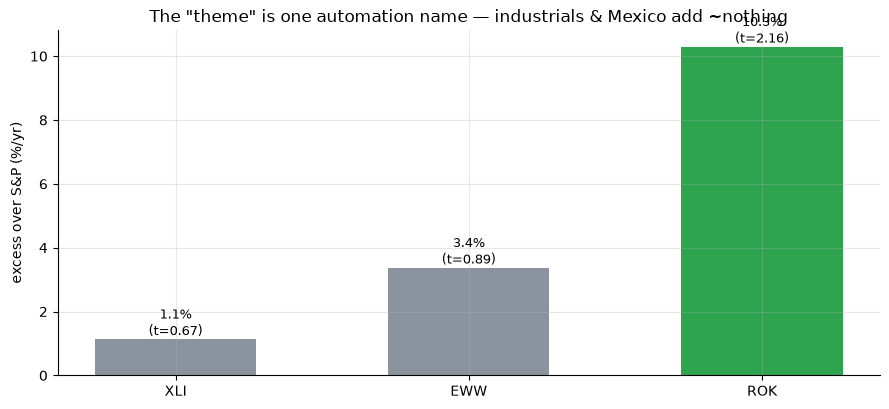

per-sleeve excess vs SPY: {'XLI': '1.1%/yr (t=0.67)', 'EWW': '3.4%/yr (t=0.89)', 'ROK': '10.3%/yr (t=2.16)'}


In [5]:
if HAVE_REAL:
    rets = data.load_prices().pct_change(); spy = rets['SPY']
    names = data.RESHORING_NAMES
    exc = [(rets[nm]-spy).dropna().mean()*252*100 for nm in names]
    tt = [st.hac_t((rets[nm]-spy).dropna().values) for nm in names]
else:
    names = [s[0] for s in R['sleeves']]; exc = [s[1] for s in R['sleeves']]; tt = [s[2] for s in R['sleeves']]
cols = [GREEN if t>=2 else GREY for t in tt]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, exc, color=cols, width=.55)
ax.set_ylabel('excess over S&P (%/yr)')
ax.set_title('The "theme" is one automation name — industrials & Mexico add ~nothing')
for i,(e,t) in enumerate(zip(exc,tt)):
    ax.annotate(f'{e:.1f}%\n(t={t:.2f})',(i,e),ha='center',va='bottom',fontsize=9)
plt.tight_layout(); plt.show()
print('per-sleeve excess vs SPY:', {n:f'{e:.1f}%/yr (t={t:.2f})' for n,e,t in zip(names,exc,tt)})

**XLI** (US industrials) and **EWW** (Mexico) — the literal core of the reshoring thesis — show **no** reliable edge (*t* = 0.67 and 0.89). The whole basket headline is carried by **ROK**, a single automation stock that happened to compound (*t* = 2.16). That's not a theme — that's one survivor.

## 5 · The verdict

- **Signal — Weak.** The basket out-earns the S&P (~+4.9%/yr) — but strip the beta and the alpha (**+4.6%/yr**) **isn't statistically solid** (*t* = 1.93), is **~zero vs a global index**, and is carried by one stock. Real as beta, weak as alpha.
- **Tradability — Mirage.** What survives is **beta you could buy directly and cheaply**, not reshoring alpha — and in the era you'd actually trade the story, the edge is *negative*.
- **Structural edge? — Busted.** Mostly beta, one stock, and it **reverses exactly when the narrative arrives**. The trade worked before it had a name.

## 6 · Could you actually trade it? — what you're really buying

Suppose you ignore all of the above and just buy the basket and short the index to isolate the "edge." Costs are trivial (it's buy-and-hold), so they're not the problem. The problem is *what the edge is made of* — and once you net out the market, in the era you'd trade, there's nothing left.

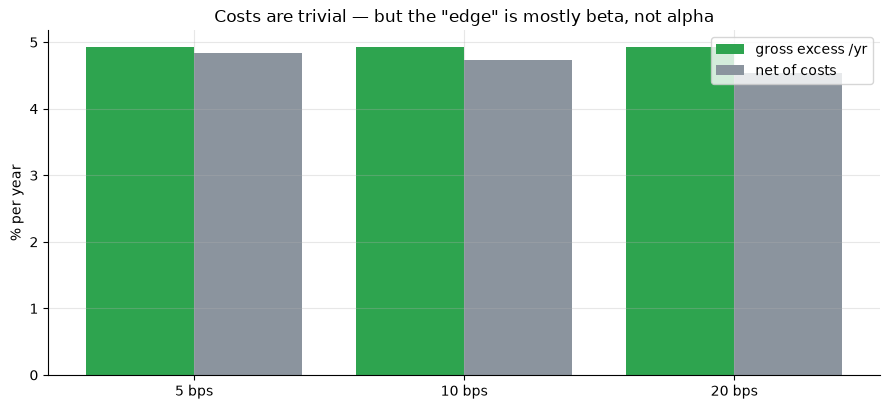

costs barely dent it — but what survives is beta you can buy cheaper as a plain index


In [6]:
if HAVE_REAL:
    g = [st.net_of_costs(F,'mkt',cost_bps=cb)['gross_excess_ann']*100 for cb in (5,10,20)]
    nn = [st.net_of_costs(F,'mkt',cost_bps=cb)['net_excess_ann']*100 for cb in (5,10,20)]
else:
    g = [c[1] for c in R['costs']]; nn = [c[2] for c in R['costs']]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(x-.2, g, .4, color=GREEN, label='gross excess /yr')
ax.bar(x+.2, nn, .4, color=GREY, label='net of costs')
ax.set_xticks(x); ax.set_xticklabels(['5 bps','10 bps','20 bps'])
ax.set_ylabel('% per year'); ax.set_title('Costs are trivial — but the "edge" is mostly beta, not alpha')
ax.legend(); plt.tight_layout(); plt.show()
print('costs barely dent it — but what survives is beta you can buy cheaper as a plain index')

The bars barely move with cost — a buy-and-hold tilt hardly trades. But that's a red herring. You're not being paid a reshoring premium; you're being paid for **beta** (which an index fund gives you cheaper) plus **one stock's** luck. Strip those and there's no premium to deploy — and **post-2018 the plain index actually out-Sharpes the basket**. There's no NAV-scale trade here.

## 7 · Going further 🚪

- **The family.** [Study 394 — Defense-Basket](../394-defense-basket/) asks the same question of "war stocks rally on war news"; [Study 393 — AI-Datacenter-Basket](../393-ai-datacenter-basket/) and [Study 356 — GLP-1-Basket](../356-glp1-basket/) tear down other hot theme baskets. Same lesson each time: owning the narrative buys you sector beta, rarely alpha.
- **Swap the proxy.** Replace ROK with a diversified automation ETF (e.g. ROBO/BOTZ) or use a real reshoring ETF (RSHO) on its short live window — the single-name luck washes out and the "edge" weakens further.
- **Build your own benchmark.** Beating the *US* index with a US-tilted basket is partly a US bet; race it against an industrials-only or a beta-matched benchmark and the alpha shrinks again.

*Think reshoring is a real, distinct edge? Regress out the market, show a positive alpha that **holds after 2018** and **isn't one stock** — then we'll talk.*